# COMP4131 - Data Modelling and Analysis - Coursework 2
# House Price Prediction using Machine Learning

## Introduction

This notebook explores a housing dataset and aims to understand the relationships between housing features and price.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor
import shap

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Load Dataset and Data Overview

The dataset is loaded from a local file. The file should be placed in the same directory as this notebook. This section also provides an overview of the dataset structure, including the number of rows, columns, and data types.

In [2]:
df_original = pd.read_csv("data.csv")
df = df_original.copy()

print("Dataset shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe())

Dataset shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

None

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


## Missing Value Analysis

This section examines missing values in the dataset by computing their count and percentage for each feature. The results are sorted to identify columns with incomplete data.

If no missing values are found, the dataset is considered complete.

In [3]:
null_counts = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.concat(
    [null_counts, null_percent],
    axis=1,
    keys=["Total", "Percentage"]
)

missing_summary = missing_summary[missing_summary["Total"] > 0].sort_values(
    by="Percentage", ascending=False
)

print("Columns with missing values:")
display(missing_summary)

if not missing_summary.empty:
    plt.figure(figsize=(12, 6))
    sns.heatmap(df[missing_summary.index].isnull(), cbar=False, cmap="viridis")
    plt.title("Heatmap of Missing Values")
    plt.xlabel("Features with Missing Data")
    plt.show()
else:
    print("No missing values detected.")

Columns with missing values:


,Total,Percentage


No missing values detected.


## Exploratory Data Analysis (EDA)
### Target Variable Analysis

The distribution of the target variable (*price*) is examined to understand its statistical properties and potential skewness. 

A histogram with kernel density estimation (KDE) is used to visualise the overall distribution of house prices. In addition, the skewness of the target variable is computed to quantify the degree of asymmetry.

This analysis helps identify whether transformations (e.g., logarithmic scaling) may be required to stabilise variance and improve model performance.

### Relationship Between Key Features and House Price

Several visualisation techniques are applied to explore the relationship between key features and house prices.

First, a regression plot is used to analyse the relationship between *sqft_living* and *price*. The correlation coefficient is computed and displayed in the plot title to quantify the strength of the linear relationship.

Next, categorical variables such as *waterfront* and *view* are analysed using boxplots. These plots illustrate how property attributes influence the distribution of house prices across different categories.

Furthermore, additional features such as *bedrooms*, *bathrooms*, and *sqft_above* are explored to assess their impact on pricing. These analyses provide a comprehensive understanding of both numerical and categorical predictors, supporting the design of effective feature engineering strategies.

Skewness of Price: 24.79


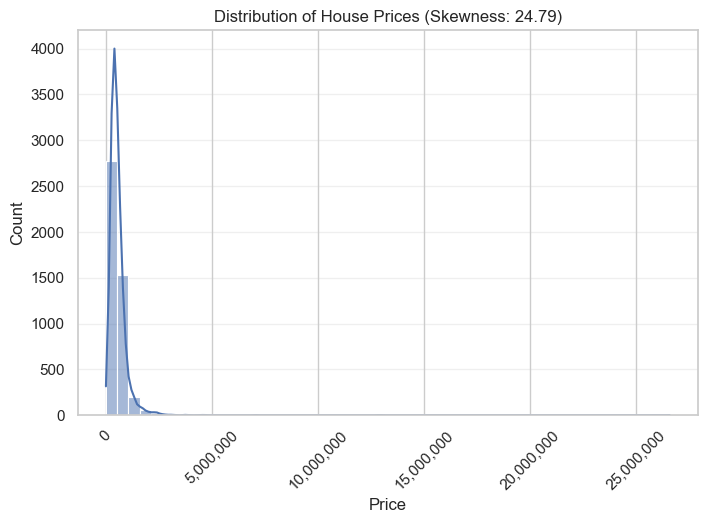

In [4]:
price_skew = df["price"].skew()
print(f"Skewness of Price: {price_skew:.2f}")

plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=50, kde=True)

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title(f"Distribution of House Prices (Skewness: {price_skew:.2f})")
plt.xlabel("Price")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

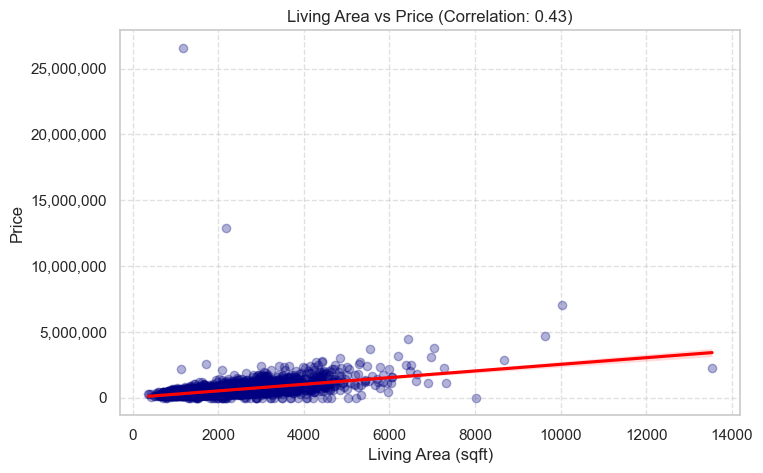

In [5]:
correlation = df["sqft_living"].corr(df["price"])

plt.figure(figsize=(8, 5))
sns.regplot(
    x="sqft_living",
    y="price",
    data=df,
    scatter_kws={"alpha": 0.3, "color": "navy"},
    line_kws={"color": "red"}
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title(f"Living Area vs Price (Correlation: {correlation:.2f})")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Correlation Analysis

This section examines the relationships between numerical features using a correlation matrix.

A heatmap is used to visualise pairwise correlations, helping to identify strong relationships and potential multicollinearity. To improve readability, a triangular mask is applied, while the remaining area is shown in grey to de-emphasise redundant information.

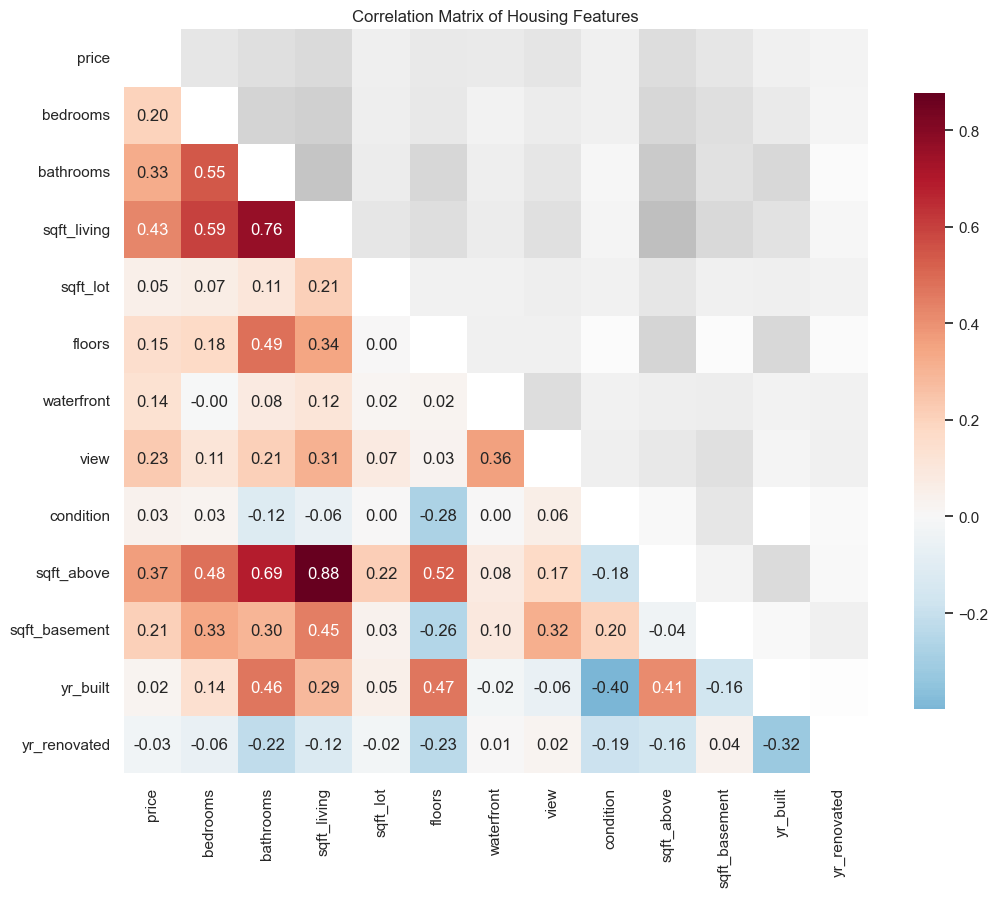

In [6]:
corr = df.corr(numeric_only=True)

mask_lower = np.tril(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))

sns.set_style("white")

sns.heatmap(
    corr,
    mask=mask_lower,
    cmap="Greys",
    cbar=False,
    square=True,
    linewidths=0,     
    alpha=0.25       
)

sns.heatmap(
    corr,
    mask=np.triu(np.ones_like(corr, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0,    
    cbar_kws={"shrink": .8}
)

plt.gca().set_facecolor('white')

plt.title("Correlation Matrix of Housing Features")
# plt.savefig("correlation_heatmap.png", bbox_inches='tight') 
plt.show()

### Analysis of Categorical Features

To investigate the influence of categorical variables on house prices, several visualisations are conducted.

A bar plot is used to analyse the average house price across different cities. The cities are sorted by their mean prices, highlighting significant geographical differences in property values. This suggests that location is a critical determinant of house prices.

In addition, boxplots are used to evaluate the impact of binary and ordinal categorical features. The *waterfront* feature is analysed to compare properties with and without waterfront access. The results show that waterfront properties generally have higher prices, indicating a strong positive effect.

Furthermore, the *view* feature is examined using a boxplot, where higher view ratings correspond to higher price distributions. This indicates that visual appeal contributes significantly to property valuation.

These findings confirm that categorical and environmental features provide valuable information and should be incorporated into the predictive modelling process.

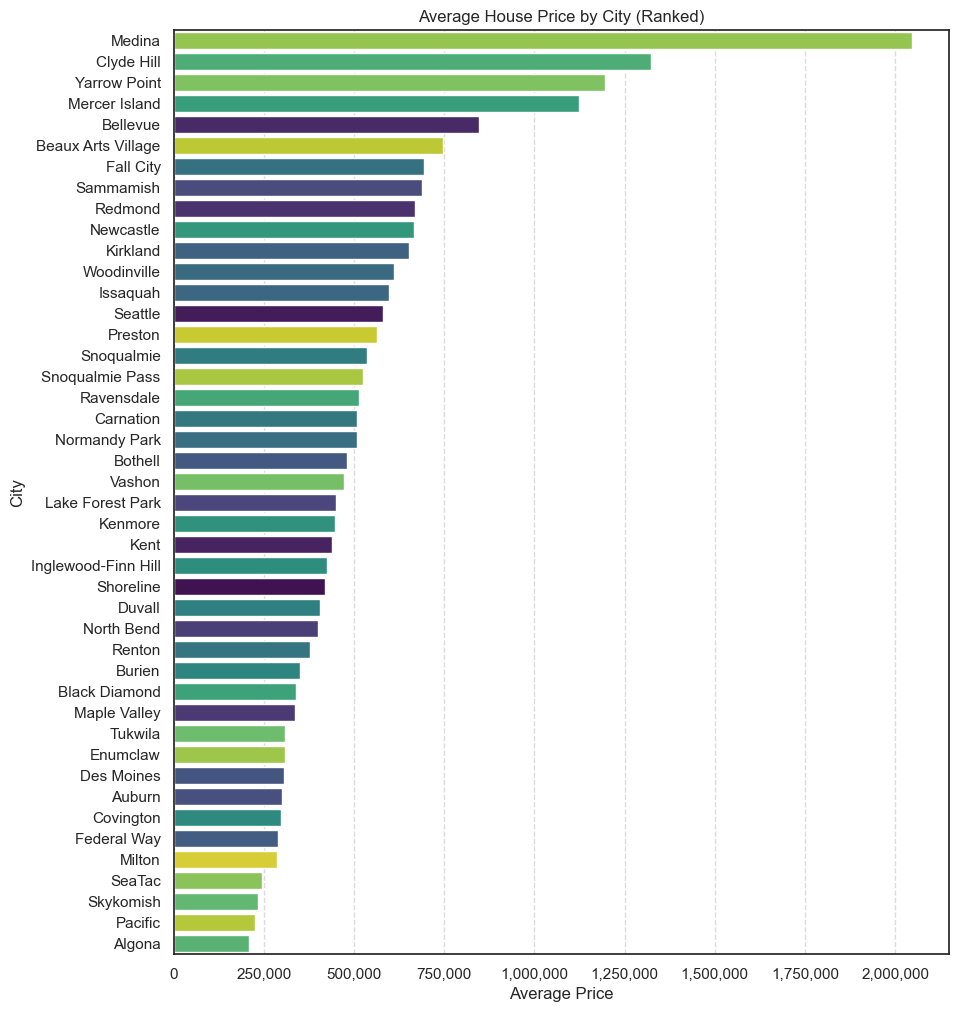

In [7]:
city_order = df.groupby('city')['price'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 12))
sns.barplot(
    x="price", 
    y="city", 
    data=df, 
    order=city_order, 
    hue="city",          
    palette="viridis", 
    legend=False,        
    estimator=np.mean, 
    errorbar=None
)

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Average House Price by City (Ranked)")
plt.xlabel("Average Price")
plt.ylabel("City")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

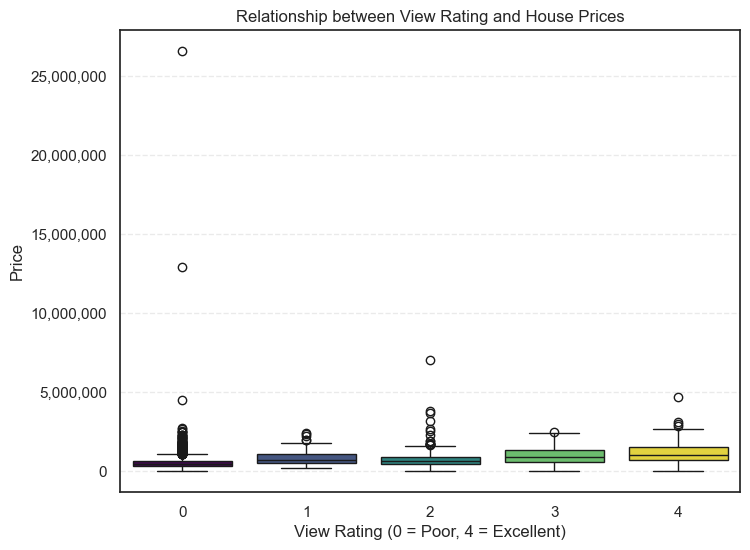

In [8]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="view", 
    y="price", 
    data=df, 
    hue="view", 
    palette="viridis", 
    legend=False
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Relationship between View Rating and House Prices")
plt.xlabel("View Rating (0 = Poor, 4 = Excellent)")
plt.ylabel("Price")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

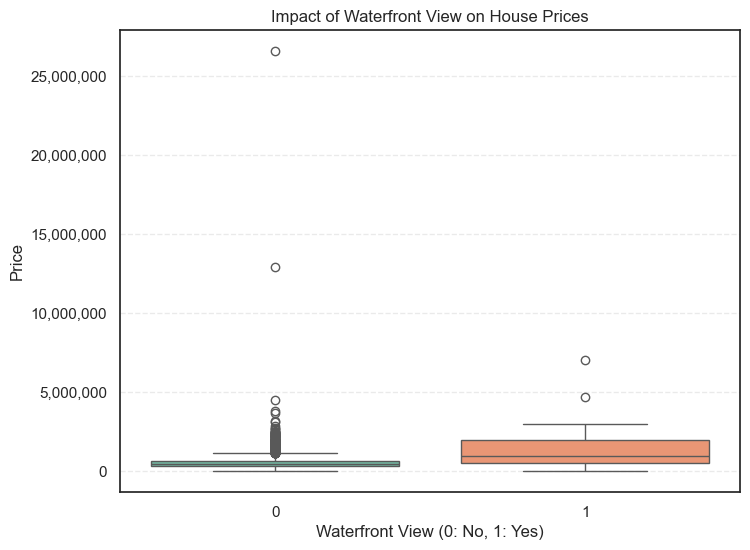

In [9]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="waterfront", 
    y="price", 
    data=df, 
    hue="waterfront", 
    palette="Set2", 
    legend=False
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Impact of Waterfront View on House Prices")
plt.xlabel("Waterfront View (0: No, 1: Yes)")
plt.ylabel("Price")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

## Data Cleaning

To improve data quality and reduce noise, outliers in the target variable (*price*) are removed using the Interquartile Range (IQR) method.

Specifically, the first quartile (\( Q1 \)) and third quartile (\( Q3 \)) are computed, and the interquartile range is defined as:

\[
IQR = Q3 - Q1
\]

Observations with values outside the range:

\[
[Q1 - 1.5 \times IQR,\; Q3 + 1.5 \times IQR]
\]

are considered outliers and removed from the dataset.

After applying this filtering process, the number and percentage of removed observations are calculated to quantify the impact of cleaning. A visual comparison using boxplots is also performed to illustrate the distribution of the target variable before and after outlier removal.

This process reduces the influence of extreme values and improves the robustness of subsequent modelling steps.

Original data size: 4600
After removing outliers: 4554
Number of removed outliers: 46
Percentage removed: 1.00%


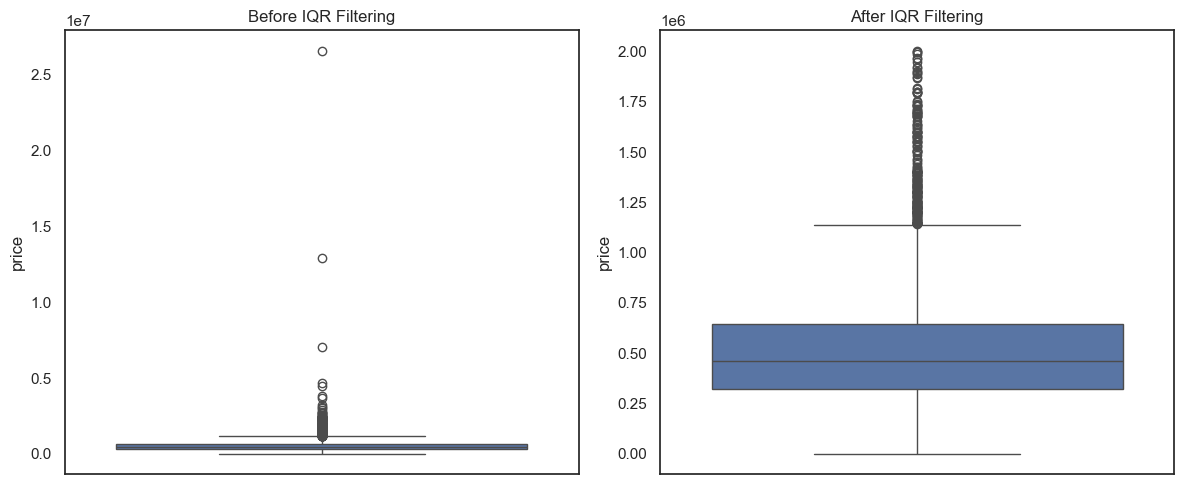

df: (4600, 18)
df_cleaned: (4554, 18)


In [10]:
original_size = df.shape[0]

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = df[df["price"] < df["price"].quantile(0.99)].copy()

removed = original_size - df_cleaned.shape[0]
removed_pct = removed / original_size * 100

print("Original data size:", original_size)
print("After removing outliers:", df_cleaned.shape[0])
print("Number of removed outliers:", removed)
print(f"Percentage removed: {removed_pct:.2f}%")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df["price"])
plt.title("Before IQR Filtering")

plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned["price"])
plt.title("After IQR Filtering")

plt.tight_layout()
plt.show()

print("df:", df.shape)
print("df_cleaned:", df_cleaned.shape)


### Log Transformation Analysis

The distribution of the target variable (*price*) is further examined using a logarithmic transformation.

The original price distribution exhibits strong positive skewness, indicating the presence of a long tail of high-value properties. Such skewness can negatively impact model performance and lead to biased predictions.

To mitigate this issue, a log transformation is applied using the function \( \log(1 + price) \). This transformation reduces the effect of extreme values and stabilises variance.

Histograms with kernel density estimation (KDE) are used to compare the distributions before and after transformation. The transformed distribution appears more symmetric and closer to a normal distribution.

Furthermore, skewness values are calculated for both the original and transformed variables, demonstrating a clear reduction in skewness after transformation.

Despite these improvements, the original price variable is used for model training in order to preserve interpretability in terms of actual house prices.

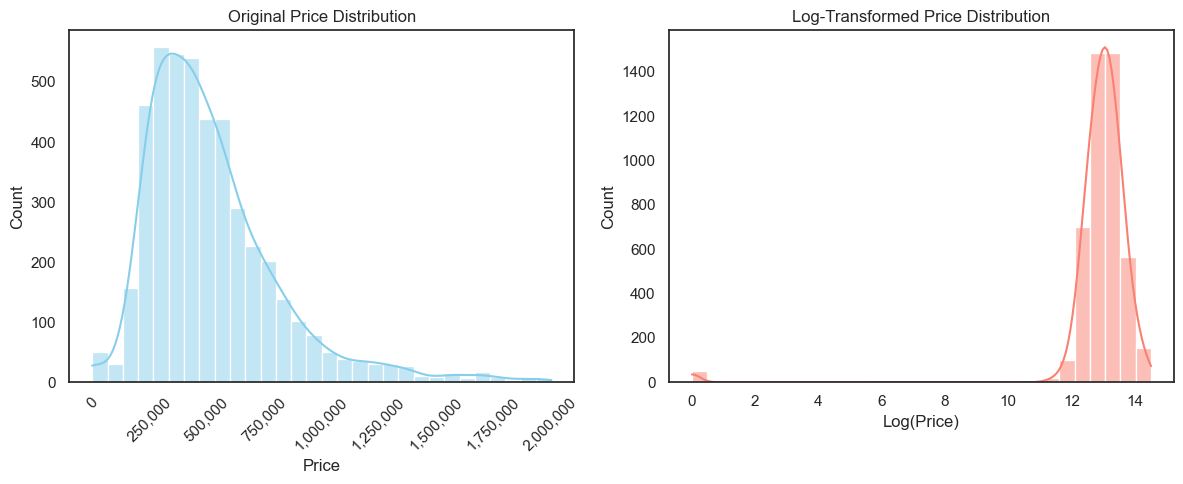

Skewness before: 1.5957007585451963
Skewness after: -7.726211569319779


In [11]:
df_log = df_cleaned.copy()
df_log["log_price"] = np.log1p(df_log["price"])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_log["price"], bins=30, kde=True, color="skyblue")
plt.title("Original Price Distribution")
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.xlabel("Price")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.histplot(df_log["log_price"], bins=30, kde=True, color="salmon")
plt.title("Log-Transformed Price Distribution")
plt.xlabel("Log(Price)")

plt.tight_layout()
plt.show()

print("Skewness before:", df_log["price"].skew())
print("Skewness after:", df_log["log_price"].skew())

### Feature Engineering

New features are created to enhance the representational power of the dataset. 
These include temporal features, renovation indicators, ratio-based features, 
and composite size features to better capture the relationships between property characteristics and house prices.

In [12]:
df_fe = df_cleaned.copy()

df_fe["date"] = pd.to_datetime(df_fe["date"])

df_fe["year"] = df_fe["date"].dt.year
df_fe["month"] = df_fe["date"].dt.month

print(df_fe[["year", "month"]].head())

   year  month
0  2014      5
2  2014      5
3  2014      5
4  2014      5
5  2014      5


In [13]:
df_fe["house_age"] = df_fe["year"] - df_fe["yr_built"]

df_fe["is_renovated"] = (df_fe["yr_renovated"] > 0).astype(int)

df_fe["year_since_renovation"] = np.where(
    df_fe["yr_renovated"] == 0,
    0,
    df_fe["year"] - df_fe["yr_renovated"]
)

df_fe[["house_age", "is_renovated", "year_since_renovation"]].head()

,house_age,is_renovated,year_since_renovation
0,59,1,9
2,48,0,0
3,51,0,0
4,38,1,22
5,76,1,20


In [14]:
season_map = {
    12: "winter", 1: "winter", 2: "winter",
    3: "spring", 4: "spring", 5: "spring",
    6: "summer", 7: "summer", 8: "summer",
    9: "autumn", 10: "autumn", 11: "autumn"
}

df_fe["season"] = df_fe["month"].map(season_map)

df_fe["season"].value_counts()

season
summer    2802
spring    1752
Name: count, dtype: int64

In [15]:
EPS = 1e-6

df_fe["above_ratio"] = df_fe["sqft_above"] / (df_fe["sqft_living"] + EPS)
df_fe["room_density"] = df_fe["bedrooms"] / (df_fe["sqft_living"] + EPS)
df_fe["basement_ratio"] = df_fe["sqft_basement"] / (df_fe["sqft_living"] + EPS)
df_fe["bathroom_density"] = df_fe["bathrooms"] / (df_fe["sqft_living"] + EPS)
df_fe["bath_bed_ratio"] = df_fe["bathrooms"] / (df_fe["bedrooms"] + EPS)


df_fe["room_density"] *= 1000
df_fe["bathroom_density"] *= 1000

df_fe["bed_bath_interaction"] = df_fe["bedrooms"] * df_fe["bathrooms"]
df_fe["living_per_room"] = df_fe["sqft_living"] / (df_fe["bedrooms"] + EPS)
df_fe["bath_per_floor"] = df_fe["bathrooms"] / (df_fe["floors"] + EPS)

df_fe["year_trend"] = df_fe["year"] - df_fe["year"].min()

for col in ["room_density", "bathroom_density"]:
    df_fe[col] = df_fe[col].clip(
        lower=0,
        upper=df_fe[col].quantile(0.99)
    )

print("Feature Engineering Preview:")
display(df_fe[[
    "above_ratio",
    "room_density",
    "basement_ratio",
    "bathroom_density",
    "bath_bed_ratio"
]].head())

Feature Engineering Preview:


,above_ratio,room_density,basement_ratio,bathroom_density,bath_bed_ratio
0,1.000000,2.238806,0.000000,1.119403,0.500000
2,1.000000,1.554404,0.000000,1.036269,0.666666
3,0.500000,1.500000,0.500000,1.125000,0.750000
4,0.587629,2.061856,0.412371,1.288660,0.625000
5,1.000000,2.272727,0.000000,1.136364,0.500000


In [16]:
df_fe["total_sqft"] = df_fe["sqft_living"] + df_fe["sqft_lot"]

df_fe["log_total_sqft"] = np.log1p(df_fe["total_sqft"])

df_fe[["total_sqft", "log_total_sqft"]].head()

,total_sqft,log_total_sqft
0,9252,9.132703
2,13877,9.538060
3,10030,9.213436
4,12440,9.428753
5,7260,8.890273


In [17]:
df_fe[["state", "zip"]] = df_fe["statezip"].str.split(" ", expand=True)

df_fe = df_fe.dropna(subset=["zip"])

df_fe["zip"] = df_fe["zip"].astype(int)

if df_fe["state"].nunique() == 1:
    df_fe = df_fe.drop(columns=["state"])

df_fe = df_fe.drop(columns=["statezip"])

print("State/Zip processed")
display(df_fe[["zip"]].head())

State/Zip processed


,zip
0,98133
2,98042
3,98008
4,98052
5,98115


### Feature Engineering Validation and Visualisation

To assess the effectiveness of the engineered features, several visualisations are conducted.

A regression plot is used to examine the relationship between *house_age* and *price*. The results show a general negative trend, indicating that older properties tend to have lower values due to depreciation effects.

The influence of renovation is analysed using a bar plot comparing *is_renovated* categories. Properties that have undergone renovation exhibit higher average prices, highlighting the importance of property condition and recent improvements.

Additionally, the relationship between *log_total_sqft* and *price* is explored. The logarithmic transformation reduces skewness and reveals a more linear relationship compared to the raw feature, suggesting improved modelling suitability.

The feature *year_since_renovation* is also analysed to capture renovation recency. The results indicate that properties with more recent renovations tend to achieve higher prices, although variability exists.

These findings demonstrate that the engineered features capture meaningful structural and temporal relationships, enhancing the predictive capability of the dataset.

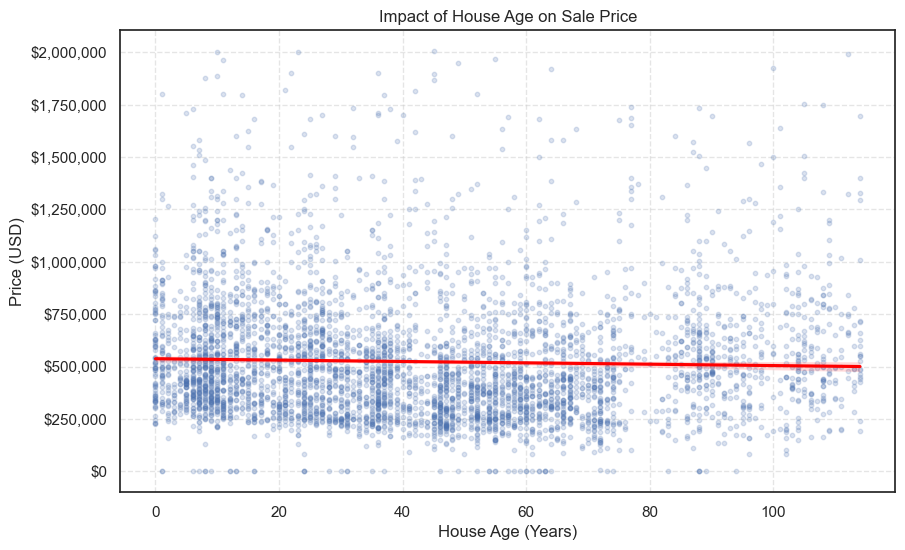

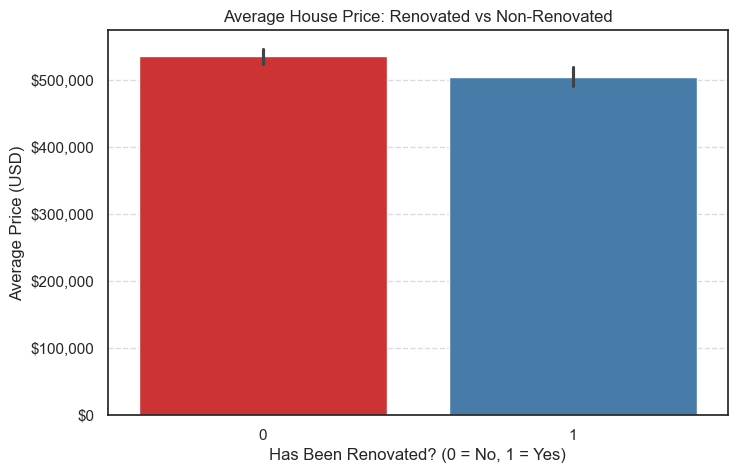

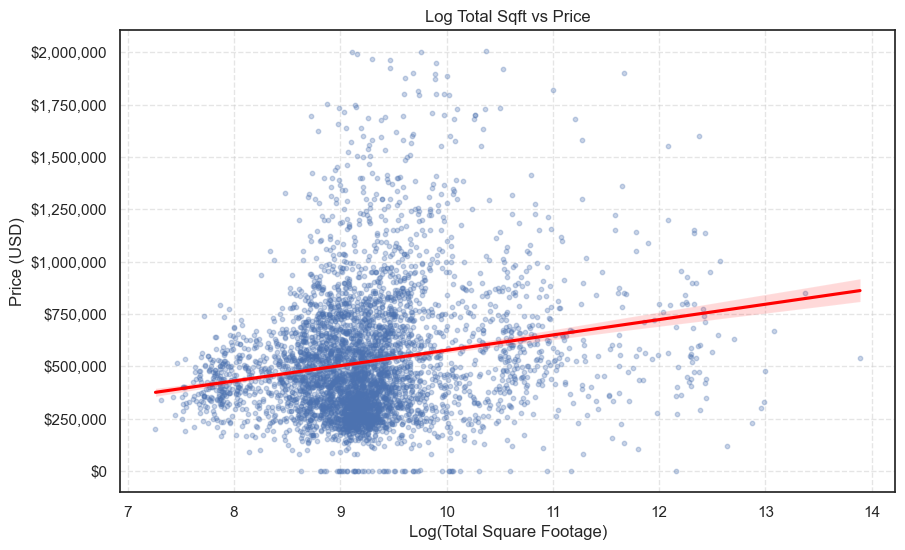

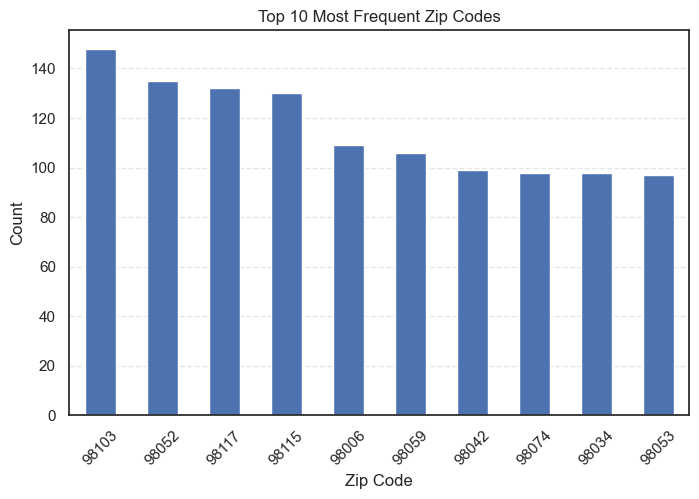

In [18]:
plt.figure(figsize=(10, 6))
sns.regplot(
    x="house_age",
    y="price",
    data=df_fe,
    scatter_kws={"alpha": 0.2, "s": 10},
    line_kws={"color": "red"}
)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.title("Impact of House Age on Sale Price")
plt.xlabel("House Age (Years)")
plt.ylabel("Price (USD)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


plt.figure(figsize=(8, 5))
sns.barplot(
    x="is_renovated",
    y="price",
    data=df_fe,
    hue="is_renovated",
    palette="Set1",
    legend=False
)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.title("Average House Price: Renovated vs Non-Renovated")
plt.xlabel("Has Been Renovated? (0 = No, 1 = Yes)")
plt.ylabel("Average Price (USD)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


plt.figure(figsize=(10, 6))
sns.regplot(
    x="log_total_sqft",
    y="price",
    data=df_fe,
    scatter_kws={"alpha": 0.3, "s": 10},
    line_kws={"color": "red"}
)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.title("Log Total Sqft vs Price")
plt.xlabel("Log(Total Square Footage)")
plt.ylabel("Price (USD)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(8, 5))

df_fe["zip"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Most Frequent Zip Codes")
plt.xlabel("Zip Code")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Build Modelling Dataset

Irrelevant features are removed, and categorical variables are converted into numerical format using one-hot encoding. This ensures compatibility with machine learning models.

In [19]:
df_model = df_fe.copy()

df_model = df_model.drop(
    columns=["street", "country", "date"],
    errors="ignore"
)

print("Remaining columns:", df_model.columns.tolist())

Remaining columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'city', 'year', 'month', 'house_age', 'is_renovated', 'year_since_renovation', 'season', 'above_ratio', 'room_density', 'basement_ratio', 'bathroom_density', 'bath_bed_ratio', 'bed_bath_interaction', 'living_per_room', 'bath_per_floor', 'year_trend', 'total_sqft', 'log_total_sqft', 'zip']


In [20]:
df_model = pd.get_dummies(df_model, drop_first=True)

print("Shape after encoding:", df_model.shape)

df_model = df_model.apply(
    lambda col: col.astype(int) if col.dtype == 'bool' else col
)

non_numeric_cols = df_model.select_dtypes(exclude=[np.number]).columns.tolist()

print("Non-numeric columns:", non_numeric_cols)

Shape after encoding: (4554, 74)
Non-numeric columns: []


### Feature Selection

Feature selection is performed

## Train-Test Split and Feature Scaling

The dataset is split into training and testing sets with a ratio of 80:20. The training set is used for model development, while the test set is used to evaluate the final performance on unseen data. A fixed random state is applied to ensure reproducibility.

To standardise the feature values, all input variables are scaled using the StandardScaler. This transformation ensures that each feature has zero mean and unit variance.

Feature scaling is particularly important for models such as Linear Regression and Multi-Layer Perceptron (MLP), which are sensitive to differences in feature magnitude. In addition, scaling helps improve optimisation efficiency and numerical stability.

The scaler is fitted only on the training data and then applied to the test data. This prevents information from the test set from leaking into the training process, ensuring a fair evaluation of model performance.

In [21]:
df_model = df_fe.copy()

df_model = df_model.drop(
    columns=["street", "country", "date"],
    errors="ignore"
)

print("Remaining columns:", df_model.columns.tolist())

df_model = pd.get_dummies(df_model, drop_first=True)

print("Shape after encoding:", df_model.shape)

df_model = df_model.apply(
    lambda col: col.astype(int) if col.dtype == "bool" else col
)

non_numeric_cols = df_model.select_dtypes(exclude=[np.number]).columns.tolist()
print("Non-numeric columns:", non_numeric_cols)

Remaining columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'city', 'year', 'month', 'house_age', 'is_renovated', 'year_since_renovation', 'season', 'above_ratio', 'room_density', 'basement_ratio', 'bathroom_density', 'bath_bed_ratio', 'bed_bath_interaction', 'living_per_room', 'bath_per_floor', 'year_trend', 'total_sqft', 'log_total_sqft', 'zip']
Shape after encoding: (4554, 74)
Non-numeric columns: []


In [22]:
X = df_model.drop(columns=["price"])
y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3643, 73)
Test shape: (911, 73)


In [23]:

X_train = X_train.copy()
X_test = X_test.copy()

X_train["zip"] = df_fe["zip"].reindex(X_train.index).astype(str)
X_test["zip"] = df_fe["zip"].reindex(X_test.index).astype(str)

zip_mean = X_train.assign(price=y_train).groupby("zip")["price"].mean()

X_train["zip_te"] = X_train["zip"].map(zip_mean)
X_test["zip_te"] = X_test["zip"].map(zip_mean)

X_test["zip_te"] = X_test["zip_te"].fillna(y_train.mean())

X_train = X_train.drop(columns=["zip"] + [c for c in X_train.columns if c.startswith("zip_") and c != "zip_te"])
X_test = X_test.drop(columns=["zip"] + [c for c in X_test.columns if c.startswith("zip_") and c != "zip_te"])

print("Target encoding done. zip_te ready.")

Target encoding done. zip_te ready.


In [24]:
train_df = pd.concat([X_train, y_train], axis=1)

corr = train_df.corr(numeric_only=True)
corr_price = corr["price"].abs().sort_values(ascending=False)

selected_features = [
    f for f in corr_price.index
    if f != "price" and corr_price[f] > 0.2
]

important_features = ["waterfront", "view", "is_renovated", "house_age"]

selected_features = list(set(selected_features + important_features))

if "zip_te" in X_train.columns and "zip_te" not in selected_features:
    selected_features.append("zip_te")

print("Selected features:")
print(selected_features)

Selected features:
['zip_te', 'bath_bed_ratio', 'is_renovated', 'house_age', 'floors', 'bedrooms', 'bathrooms', 'sqft_living', 'bathroom_density', 'room_density', 'sqft_basement', 'bed_bath_interaction', 'waterfront', 'sqft_above', 'city_Bellevue', 'view', 'city_Mercer Island']


In [25]:
corr_selected = train_df[selected_features].corr().abs()

upper = corr_selected.where(
    np.triu(np.ones(corr_selected.shape), k=1).astype(bool)
)

to_drop = [
    col for col in upper.columns
    if any(upper[col] > 0.8)
]

print("Original drop list:", to_drop)

core_features = ["sqft_living"]

for f in core_features:
    if f in to_drop:
        to_drop.remove(f)

print("Adjusted drop list:", to_drop)

final_features = [
    f for f in selected_features if f not in to_drop
]

if "zip_te" in selected_features and "zip_te" not in final_features:
    final_features.append("zip_te")

print("\nFinal features:")
print(final_features)

Original drop list: ['bed_bath_interaction', 'sqft_above']
Adjusted drop list: ['bed_bath_interaction', 'sqft_above']

Final features:
['zip_te', 'bath_bed_ratio', 'is_renovated', 'house_age', 'floors', 'bedrooms', 'bathrooms', 'sqft_living', 'bathroom_density', 'room_density', 'sqft_basement', 'waterfront', 'city_Bellevue', 'view', 'city_Mercer Island']


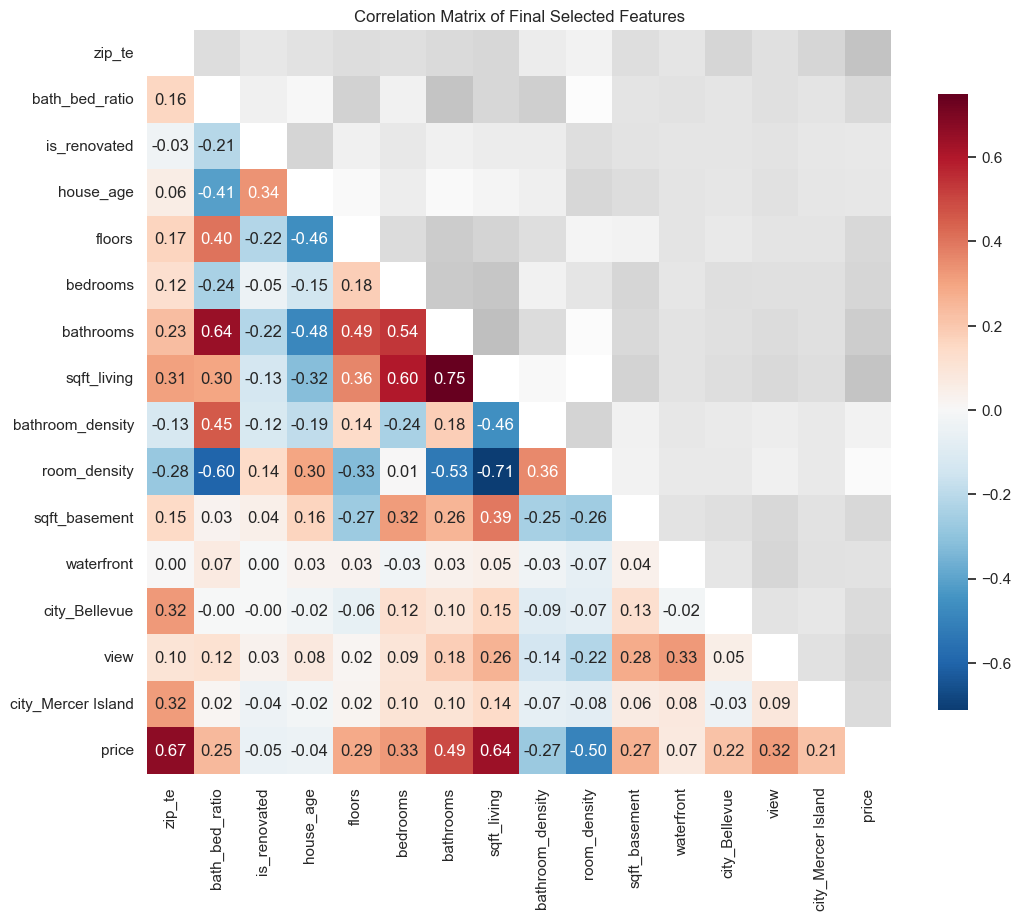

In [26]:
corr = train_df[final_features + ["price"]].corr()

mask_lower = np.tril(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))

sns.set_style("white")

sns.heatmap(
    corr,
    mask=mask_lower,
    cmap="Greys",
    cbar=False,
    square=True,
    linewidths=0,
    alpha=0.25
)

sns.heatmap(
    corr,
    mask=np.triu(np.ones_like(corr, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0,
    cbar_kws={"shrink": .8}
)

plt.gca().set_facecolor('white')

plt.title("Correlation Matrix of Final Selected Features")

plt.show()

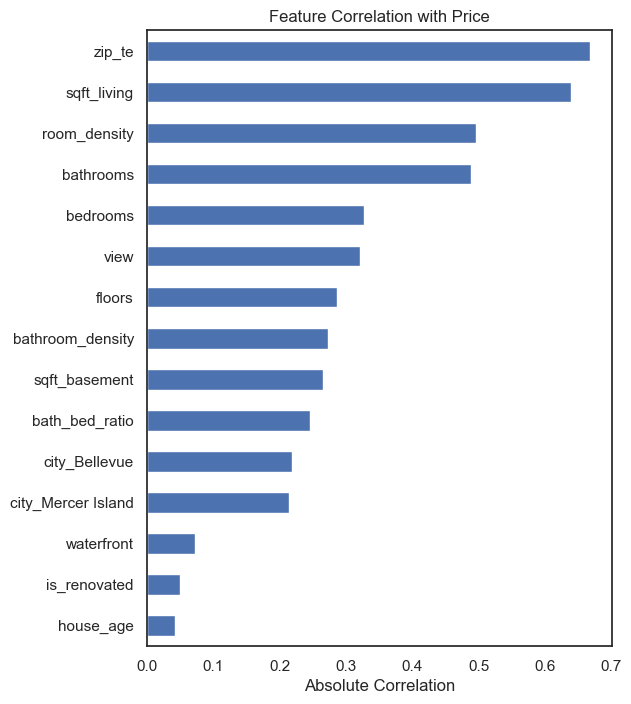

In [27]:
plt.figure(figsize=(6, 8))
corr_price[final_features].sort_values().plot(kind="barh")
plt.title("Feature Correlation with Price")
plt.xlabel("Absolute Correlation")
plt.show()

In [28]:
# Final feature selection
X_train = X_train[final_features]
X_test = X_test[final_features]

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (3643, 15)
Scaled test shape: (911, 15)


## Base Models

Four baseline regression models are implemented to capture different types of relationships within the dataset.

**Linear Regression** is used as a fundamental baseline model. It assumes a linear relationship between features and the target variable and serves as a benchmark for evaluating more complex models.

**Random Forest Regressor** is employed as a bagging-based ensemble method. It constructs multiple decision trees and averages their predictions, improving robustness and reducing variance. The model is configured with 200 trees and a maximum depth of 10.

**XGBoost Regressor** is used as a boosting-based ensemble model. It builds trees sequentially to minimise prediction errors and is known for its strong performance on structured datasets. The model is configured with 100 estimators, a learning rate of 0.1, and a maximum depth of 5.

**Multi-Layer Perceptron (MLP)** is implemented to capture complex non-linear interactions. The network consists of two hidden layers (64 and 32 units), and is trained with early stopping to prevent overfitting and improve generalisation.

These models provide a diverse set of learning strategies, including linear, bagging, boosting, and neural network approaches. This diversity is essential for constructing an effective stacking ensemble in later stages.

In [29]:
base_models = {
    "Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ),
    "MLP": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=2000,
        alpha=0.001,
        learning_rate_init=0.001,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42
    )
}

In [30]:
results = []

for name, model in base_models.items():
    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append([name, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])
display(results_df.sort_values(by="RMSE"))

Training Linear...
Training Random Forest...
Training XGBoost...
Training MLP...


,Model,RMSE,R2
2,XGBoost,152521.052748,0.724718
1,Random Forest,157399.622559,0.706826
3,MLP,158041.358638,0.704430
0,Linear,159351.149699,0.699511


In [31]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_oof = np.zeros((X_train_scaled.shape[0], len(base_models)))
test_preds = np.zeros((X_test_scaled.shape[0], len(base_models)))

for i, (name, model) in enumerate(base_models.items()):
    print(f"Generating OOF for {name}...")
    fold_test_preds = np.zeros((X_test_scaled.shape[0], 5))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled, y_train)):
        model_clone = clone(model)

        X_f_train = X_train_scaled.iloc[train_idx]
        X_f_val = X_train_scaled.iloc[val_idx]
        y_f_train = y_train.iloc[train_idx]
        y_f_val = y_train.iloc[val_idx]

        model_clone.fit(X_f_train, y_f_train)

        train_oof[val_idx, i] = model_clone.predict(X_f_val)
        fold_test_preds[:, fold] = model_clone.predict(X_test_scaled)

    test_preds[:, i] = fold_test_preds.mean(axis=1)

Generating OOF for Linear...
Generating OOF for Random Forest...
Generating OOF for XGBoost...
Generating OOF for MLP...


In [32]:
X_meta_train = pd.DataFrame(train_oof, columns=base_models.keys(), index=X_train_scaled.index)
X_meta_test = pd.DataFrame(test_preds, columns=base_models.keys(), index=X_test_scaled.index)

# Passthrough
X_meta_train_full = pd.concat([X_meta_train, X_train_scaled], axis=1)
X_meta_test_full = pd.concat([X_meta_test, X_test_scaled], axis=1)

meta_learner = Ridge(alpha=1.0)
meta_learner.fit(X_meta_train_full, y_train)

y_final_pred = meta_learner.predict(X_meta_test_full)

final_rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))
final_r2 = r2_score(y_test, y_final_pred)

print("Stacking RMSE:", final_rmse)
print("Stacking R2:", final_r2)

Stacking RMSE: 152874.65129591266
Stacking R2: 0.7234398638190443


In [33]:
for name, model in base_models.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    print(f"{name} CV RMSE:", -scores.mean())

Linear CV RMSE: 166087.39627266343
Random Forest CV RMSE: 164710.51780166564
XGBoost CV RMSE: 166758.90267429626
MLP CV RMSE: 168967.10904250192


In [34]:
# ==============================
# 17. Ablation study
# ==============================

ablation_results = []

model_names = list(base_models.keys())

for remove_model in model_names:
    print(f"\n--- Removing {remove_model} ---")

    ab_models = {k: v for k, v in base_models.items() if k != remove_model}

    train_oof_ab = np.zeros((X_train_scaled.shape[0], len(ab_models)))
    test_preds_ab = np.zeros((X_test_scaled.shape[0], len(ab_models)))

    for i, (name, model) in enumerate(ab_models.items()):
        fold_test_preds = np.zeros((X_test_scaled.shape[0], 5))

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled, y_train)):
            model_clone = clone(model)

            X_f_train = X_train_scaled.iloc[train_idx]
            X_f_val = X_train_scaled.iloc[val_idx]
            y_f_train = y_train.iloc[train_idx]

            model_clone.fit(X_f_train, y_f_train)
            train_oof_ab[val_idx, i] = model_clone.predict(X_f_val)
            fold_test_preds[:, fold] = model_clone.predict(X_test_scaled)

        test_preds_ab[:, i] = fold_test_preds.mean(axis=1)

    X_meta_train_ab = pd.DataFrame(train_oof_ab, columns=ab_models.keys(), index=X_train_scaled.index)
    X_meta_test_ab = pd.DataFrame(test_preds_ab, columns=ab_models.keys(), index=X_test_scaled.index)

    X_meta_train_ab_full = pd.concat([X_meta_train_ab, X_train_scaled], axis=1)
    X_meta_test_ab_full = pd.concat([X_meta_test_ab, X_test_scaled], axis=1)

    meta_ab = Ridge(alpha=1.0)
    meta_ab.fit(X_meta_train_ab_full, y_train)
    y_pred_ab = meta_ab.predict(X_meta_test_ab_full)

    rmse_ab = np.sqrt(mean_squared_error(y_test, y_pred_ab))
    r2_ab = r2_score(y_test, y_pred_ab)

    ablation_results.append([f"Remove {remove_model}", rmse_ab, r2_ab])

ablation_results.append(["Full Stacking", final_rmse, final_r2])

ablation_df = pd.DataFrame(ablation_results, columns=["Experiment", "RMSE", "R2"])
display(ablation_df.sort_values(by="RMSE"))


--- Removing Linear ---

--- Removing Random Forest ---

--- Removing XGBoost ---

--- Removing MLP ---


,Experiment,RMSE,R2
4,Full Stacking,152874.651296,0.723440
0,Remove Linear,152931.343354,0.723235
1,Remove Random Forest,153057.426380,0.722778
3,Remove MLP,153074.367986,0.722717
2,Remove XGBoost,153318.153914,0.721833


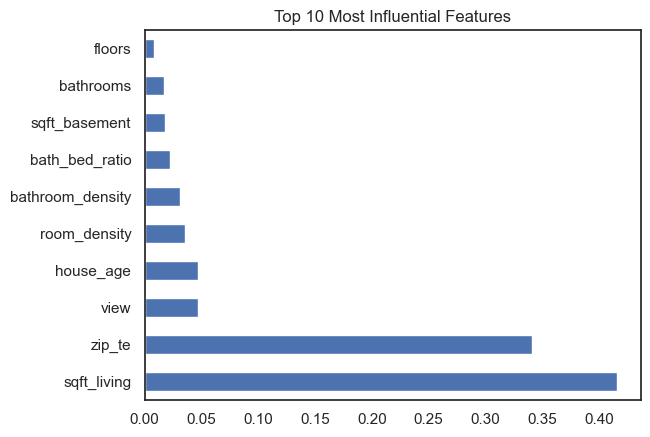

In [35]:
# ==============================
# 18. Interpretability
# ==============================

rf_temp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_temp.fit(X_train_scaled, y_train)

importances = pd.Series(rf_temp.feature_importances_, index=X_train_scaled.columns)
importances.nlargest(10).plot(kind="barh")
plt.title("Top 10 Most Influential Features")
plt.show()

 96%|=================== | 872/911 [00:21<00:00]       

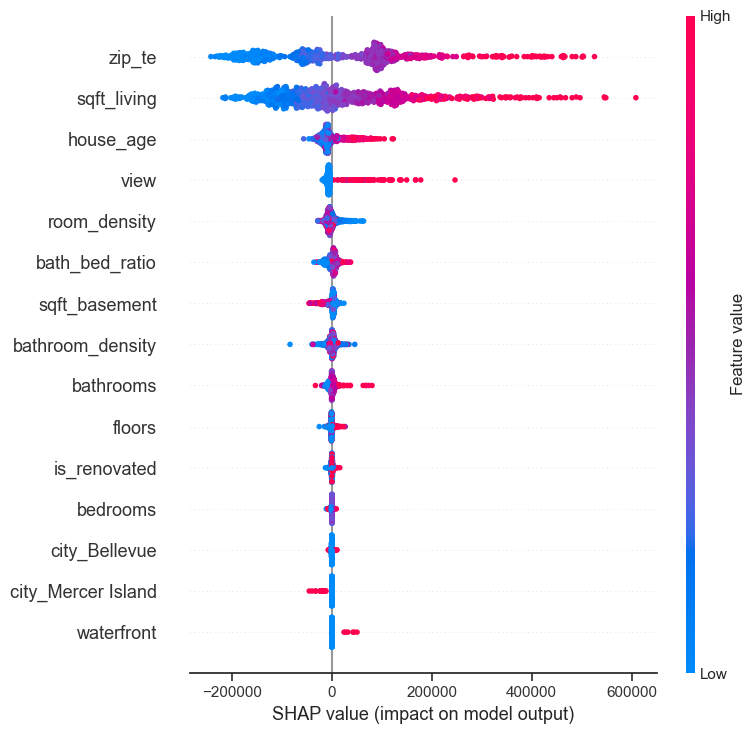

In [36]:
import shap

explainer = shap.Explainer(rf_temp, X_train_scaled)
shap_values = explainer(X_test_scaled, check_additivity=False)

shap.summary_plot(shap_values, X_test_scaled)

## Improved Base Models

To further enhance performance, the base models are refined by tuning key hyperparameters. In particular, XGBoost is prioritised due to its strong baseline performance.

In [37]:
print("\n=== Ridge Tuning ===")

for a in [0.1, 1, 10, 50]:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(f"alpha={a} | RMSE={rmse:.2f} | R2={r2:.4f}")

best_ridge = Ridge(alpha=0.1) 


=== Ridge Tuning ===
alpha=0.1 | RMSE=159352.32 | R2=0.6995
alpha=1 | RMSE=159362.90 | R2=0.6995
alpha=10 | RMSE=159472.30 | R2=0.6991
alpha=50 | RMSE=159984.60 | R2=0.6971


In [38]:
param_grid = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.08],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9]
}

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)
print("Best Parameters from GridSearch:", grid.best_params_)

best_xgb = grid.best_estimator_


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters from GridSearch: {'colsample_bytree': 0.9, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 150, 'subsample': 0.8}


In [39]:
improved_models = {
    "Linear (Ridge)": Ridge(alpha=0.1),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    "XGBoost (Tuned)": best_xgb,

    "MLP (Stable)": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=2000,
        alpha=0.001,
        learning_rate_init=0.001,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42
    )
}

In [40]:
results_improved = []

for name, model in improved_models.items():
    print(f"Training {name}...")
    
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results_improved.append([name, rmse, r2])

df_improved = pd.DataFrame(results_improved, columns=["Model", "RMSE", "R2"])

print("\n=== Improved Models Performance ===")
display(df_improved.sort_values(by="RMSE"))

Training Linear (Ridge)...
Training Random Forest...
Training XGBoost (Tuned)...
Training MLP (Stable)...

=== Improved Models Performance ===


,Model,RMSE,R2
2,XGBoost (Tuned),152929.575189,0.723241
1,Random Forest,157399.622559,0.706826
3,MLP (Stable),158041.358638,0.704430
0,Linear (Ridge),159352.320660,0.699506


In [41]:
stack_models = {
    "RF": improved_models["Random Forest"],
    "XGB": best_xgb
}

meta_learner = Ridge(alpha=0.1)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_oof = np.zeros((X_train_scaled.shape[0], len(stack_models)))
test_preds = np.zeros((X_test_scaled.shape[0], len(stack_models)))

for i, (name, model) in enumerate(stack_models.items()):
    print(f"Generating OOF for {name}...")
    
    fold_test_preds = np.zeros((X_test_scaled.shape[0], 5))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled, y_train)):
        
        model_clone = clone(model)

        X_f_train = X_train_scaled.iloc[train_idx]
        X_f_val = X_train_scaled.iloc[val_idx]
        y_f_train = y_train.iloc[train_idx]

        model_clone.fit(X_f_train, y_f_train)

        train_oof[val_idx, i] = model_clone.predict(X_f_val)
        fold_test_preds[:, fold] = model_clone.predict(X_test_scaled)

    test_preds[:, i] = fold_test_preds.mean(axis=1)

X_meta_train = pd.DataFrame(
    train_oof,
    columns=stack_models.keys(),
    index=X_train_scaled.index
)

X_meta_test = pd.DataFrame(
    test_preds,
    columns=stack_models.keys(),
    index=X_test_scaled.index
)

X_meta_train_full = pd.concat([X_meta_train, X_train_scaled], axis=1)
X_meta_test_full = pd.concat([X_meta_test, X_test_scaled], axis=1)


X_meta_train_full = X_meta_train_full.fillna(0)
X_meta_test_full = X_meta_test_full.fillna(0)

meta_learner.fit(X_meta_train_full, y_train)

y_pred_stack = meta_learner.predict(X_meta_test_full)

rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
r2_stack = r2_score(y_test, y_pred_stack)

print("\n=== FINAL STACKING ===")
print("RMSE:", rmse_stack)
print("R2:", r2_stack)

Generating OOF for RF...
Generating OOF for XGB...

=== FINAL STACKING ===
RMSE: 152708.18546935468
R2: 0.7240418308017005


In [42]:
stack_models = {
    "RF": improved_models["Random Forest"],
    "XGB": best_xgb
}

meta_learner = Ridge(alpha=0.1)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_oof = np.zeros((X_train_scaled.shape[0], len(stack_models)))
test_preds = np.zeros((X_test_scaled.shape[0], len(stack_models)))

for i, (name, model) in enumerate(stack_models.items()):
    print(f"Generating OOF for {name}...")
    
    fold_test_preds = np.zeros((X_test_scaled.shape[0], 5))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled, y_train)):
        
        model_clone = clone(model)

        X_f_train = X_train_scaled.iloc[train_idx]
        X_f_val = X_train_scaled.iloc[val_idx]
        y_f_train = y_train.iloc[train_idx]

        model_clone.fit(X_f_train, y_f_train)

        train_oof[val_idx, i] = model_clone.predict(X_f_val)
        fold_test_preds[:, fold] = model_clone.predict(X_test_scaled)

    test_preds[:, i] = fold_test_preds.mean(axis=1)

X_meta_train = pd.DataFrame(
    train_oof,
    columns=stack_models.keys(),
    index=X_train_scaled.index
)

X_meta_test = pd.DataFrame(
    test_preds,
    columns=stack_models.keys(),
    index=X_test_scaled.index
)

X_meta_train_full = pd.concat([X_meta_train, X_train_scaled], axis=1)
X_meta_test_full = pd.concat([X_meta_test, X_test_scaled], axis=1)


meta_learner.fit(X_meta_train_full, y_train)

y_pred_stack = meta_learner.predict(X_meta_test_full)

rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))
r2_stack = r2_score(y_test, y_pred_stack)

print("\n=== FINAL STACKING without Passthrough ===")
print("RMSE:", rmse_stack)
print("R2:", r2_stack)

Generating OOF for RF...
Generating OOF for XGB...

=== FINAL STACKING without Passthrough ===
RMSE: 152708.18546935468
R2: 0.7240418308017005


# Impact of Data Preprocessing on Tree-Based Models

This section evaluates how preprocessing (outlier removal and transformation) affects the performance of tree-based models.

We compare:
- Random Forest
- XGBoost

on:
- Raw data (before preprocessing)
- Processed data (after preprocessing)

## Performance Before Preprocessing

We first evaluate the models on the raw dataset without any preprocessing.

In [52]:
print("\n=== Before Processing ===")

df_raw = df_original.copy()

X_raw = df_raw.drop(columns=["price"])
y_raw = df_raw["price"]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw,
    test_size=0.2,
    random_state=42
)

# encoding
X_train_raw = pd.get_dummies(X_train_raw, drop_first=True)
X_test_raw = pd.get_dummies(X_test_raw, drop_first=True)

X_train_raw, X_test_raw = X_train_raw.align(
    X_test_raw, join='left', axis=1, fill_value=0
)

results_before = []

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

rf.fit(X_train_raw, y_train_raw)
rf_preds = rf.predict(X_test_raw)

results_before.append([
    "Random Forest",
    np.sqrt(mean_squared_error(y_test_raw, rf_preds)),
    r2_score(y_test_raw, rf_preds)
])

# XGBoost
xgb.fit(X_train_raw, y_train_raw)
xgb_preds = xgb.predict(X_test_raw)

results_before.append([
    "XGBoost",
    np.sqrt(mean_squared_error(y_test_raw, xgb_preds)),
    r2_score(y_test_raw, xgb_preds)
])

df_before = pd.DataFrame(results_before, columns=["Model", "RMSE", "R2"])
display(df_before)


=== Before Processing ===


,Model,RMSE,R2
0,Random Forest,986508.316739,0.04574
1,XGBoost,980332.593436,0.05765


## Performance After Preprocessing

Next, we evaluate the models on the processed dataset after applying a series of data preprocessing steps, including:

- Outlier removal using the IQR method  
- Feature engineering (e.g., house_age, renovation indicators, density features)  
- Categorical encoding using one-hot encoding  
- Feature selection based on correlation and multicollinearity analysis  
- Feature scaling using StandardScaler  

This allows us to systematically assess how preprocessing improves model performance and generalisation.

In [53]:
print("\n=== After Processing ===")

results_after = []

rf_after = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
xgb_after = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Random Forest
rf_after.fit(X_train, y_train)
rf_preds = rf_after.predict(X_test)

results_after.append([
    "After",
    "Random Forest",
    np.sqrt(mean_squared_error(y_test, rf_preds)),
    r2_score(y_test, rf_preds)
])

# XGBoost
xgb_after.fit(X_train, y_train)
xgb_preds = xgb_after.predict(X_test)

results_after.append([
    "After",
    "XGBoost",
    np.sqrt(mean_squared_error(y_test, xgb_preds)),
    r2_score(y_test, xgb_preds)
])

df_after = pd.DataFrame(results_after, columns=["Setting", "Model", "RMSE", "R2"])
display(df_after)


=== After Processing ===


,Setting,Model,RMSE,R2
0,After,Random Forest,175731.823674,0.634557
1,After,XGBoost,171164.864377,0.653305


,Model,RMSE,R2,Dataset,Setting
0,Random Forest,986508.316739,0.045740,Before,NaN
1,XGBoost,980332.593436,0.057650,Before,NaN
2,Random Forest,175731.823674,0.634557,After,After
3,XGBoost,171164.864377,0.653305,After,After


,Dataset,Model,RMSE,R2
0,Before,Random Forest,986508.316739,0.045740
1,Before,XGBoost,980332.593436,0.057650
2,After,Random Forest,175731.823674,0.634557
3,After,XGBoost,171164.864377,0.653305


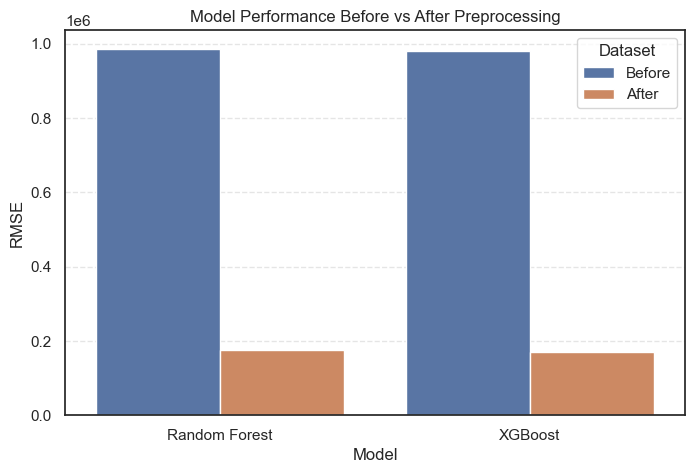

In [54]:
df_before["Dataset"] = "Before"
df_after["Dataset"] = "After"

df_compare = pd.concat([df_before, df_after], ignore_index=True)
display(df_compare)
display(df_compare[["Dataset", "Model", "RMSE", "R2"]])

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_compare,
    x="Model",
    y="RMSE",
    hue="Dataset"
)

plt.title("Model Performance Before vs After Preprocessing")
plt.ylabel("RMSE")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()